### 1. Geometria rzutu (Pozycje na rozpiętości $y$)

Wszystkie wartości dotyczą **połowy rozpiętości** ($b/2 = 1.0\,m$).

- **`y_root` (0.05):** Szerokość kadłuba (wycięcie). Skrzydło zaczyna się 5 cm od osi symetrii.
    
- **`y_break_f` (0.3):** Pozycja profilu przejściowego. Obliczana jako 30% dystansu między kadłubem a końcówką.
    
- **`y_tip_f` (0.85):** Moment, w którym kończy się płaskie skrzydło i zaczyna wyginać się winglet (85% rozpiętości).
    

### 2. Cięciwy i Kształt (Szerokość $c$ i Skos $x$)

- **`c_root`, `c_brk`, `c_tip`:** Szerokość profilu kolejno u nasady (35 cm), w miejscu przejścia (25 cm) i na starcie wingletu (15 cm).
    
- **`x_brk` (0.1):** Skos w punkcie przejścia. Krawędź natarcia jest przesunięta o 10 cm w tył względem nasady.
    
- **`x_tip` (0.35):** Skos na końcówce. Krawędź natarcia jest 35 cm w tyle względem nasady (tworzy to strzałkę skrzydła).
    

### 3. Zwichrzenie i Wznios (Kąty $t$ i Wysokość $z$)

- **`t_root`, `t_brk`, `t_tip`:** Kąty skręcenia profilu (twist/washout). Tutaj: nasada jest zadarta o $1^{\circ}$, środek to $0^{\circ}$, a końcówka jest "odpuszczona" o $-2.5^{\circ}$ dla stabilności.
    
- **`z_brk`, `z_tip`:** Wznios (dihedral). Środek skrzydła jest 2 cm wyżej niż nasada, a końcówka 5 cm wyżej (tworzy kształt litery V).
    

### 4. Parametry Wingletu

- **`h_w` (0.15):** Całkowita wysokość wingletu (15 cm ponad płaszczyznę skrzydła). 
- **`R_w` (0.04):** Promień łuku (4 cm). Określa, jak łagodnie skrzydło przechodzi w pionowy winglet.
- **`c_w_end` (0.08):** Cięciwa na samym szczycie wingletu (zwężenie do 8 cm).
- **`sweep_w` (0.05):** Dodatkowy skos wingletu. Jego czubek jest 5 cm dalej w tyle niż jego podstawa. 
- **`toe` (1.5):** Kąt zbieżności. Winglet jest skręcony o $1.5^{\circ}$ "nosem do środka" kadłuba.
    

### 5. Wybór Profilu (Baza ID)

- **`id_root`, `id_brk`, `id_tip`, `id_w`:** Indeksy plików `.dat` w Twoim folderze. Na przykład `id_root: 3` oznacza, że u nasady zostanie użyty czwarty plik z listy (licząc od 0).

In [2]:
from solver import *
from genetic_algo import fitness_function

In [3]:
from pathlib import Path
import aerosandbox as asb
# --- PARAMETRY GLOBALNE ---
B = 1.2                 # Rozpiętość całkowita [m]
TARGET_VELOCITY = 15.0  # Prędkość przelotowa [m/s]
FIXED_MASS = 0.4        # Masa elektroniki i baterii [kg]
TOTAL_MASS = 1.0        # Docelowa masa całkowita [kg]
WING_DENSITY = 1.2      # Masa struktury skrzydła [kg/m2]
AIRFOIL_FOLDER = Path("./airfoils/") # Folder z plikami .dat

# Lista dostępnych profilów (załadowana raz na starcie)
def load_airfoils(folder):
    files = list(folder.glob("*.dat"))
    return {i: asb.Airfoil(name=f.stem, coordinates=f) for i, f in enumerate(files)}

AIRFOIL_DATABASE = load_airfoils(AIRFOIL_FOLDER)

In [4]:
asb.__version__

'4.2.9'

In [5]:
print(AIRFOIL_DATABASE)
print("Rozpiętość: ", B)
print("Prędkość przelotowa: ", TARGET_VELOCITY, "m/s")
print("Masa elektroniki i baterii: ", FIXED_MASS, "kg")
print("Gęstość struktury skrzydła: ", WING_DENSITY, "kg/m2")

{0: Airfoil AG25-il (160 points), 1: Airfoil AG35 (180 points), 2: Airfoil AG36 (180 points), 3: Airfoil AH 79-100 A (97 points), 4: Airfoil FX 60-100 (97 points), 5: Airfoil GOE 444 (33 points), 6: Airfoil NACA-0009 smoothed (69 points), 7: Airfoil RG-15 8.9% (62 points), 8: Airfoil S7012 8.75% (81 points), 9: Airfoil SD8020-010-88 (61 points)}
Rozpiętość:  1.2
Prędkość przelotowa:  15.0 m/s
Masa elektroniki i baterii:  0.4 kg
Gęstość struktury skrzydła:  1.2 kg/m2


In [6]:
test_genes ={
        "y_root": 0.2,
        "y_break1_f": 0.3805288773226346,
        "y_break2_f": 0.7,
        "y_tip_f": 0.7842349408430419,
        "c_root": 0.3073893264577251,
        "c_brk1": 0.09,
        "c_brk2": 0.05246660476230659,
        "c_tip": 0.1294481335568871,
        "t_root": -0.48453509830340824,
        "t_brk1": -0.06675974635984128,
        "t_brk2": -1.4612251354416506,
        "t_tip": 0.010351292122839695,
        "x_root": 0.0,
        "x_brk1": 0.5027713943209041,
        "x_brk2": 0.816788946244838,
        "x_tip": 0.2376132653814648,
        "z_root": 0.06202428484463031,
        "z_brk1": 0.0427035210768541,
        "z_brk2": 0.22342327858301395,
        "z_tip": 0.002330944587367101,
        "winglet_target_angle": 71.42339435026572,
        "h_w": 0.14184489566463532,
        "R_w": 0.1,
        "c_w_end": 0.06611436356363037,
        "sweep_w": 0.0008685050315143328,
        "toe": -1.8304868087536794,
        "id_root": 1.119348748321722,
        "id_brk1": 5.143145612740146,
        "id_tip": 8.333450008429114,
        "id_w": 7.61774838443044
}

airplane, mass = build_airplane_curved(test_genes, 'linear')
#score, details = fitness_function(test_genes)
print(f"Samolot zbudowany pomyślnie! Szacowana masa: {mass:.3f} kg")
airplane.draw(backend='plotly')
alphas1 = np.linspace(-2, 15, 16)  # Zakres kątów natarcia
data, x_cg_target = GA_aerodynamics(airplane, TARGET_VELOCITY, alphas1)
score, score_details = fitness_function_weighted(data)
print(f"Score: {score:.2f}")
print(data)




Samolot zbudowany pomyślnie! Szacowana masa: 0.802 kg


Score: 53.98
{'ld': np.float64(27.574530386171457), 'cl': np.float64(0.49186418066373006), 'cd': np.float64(0.017837626743786666), 'cm_cg': 0.0, 'cma': np.float64(-0.3370920432674634), 'cnb': np.float64(0.17196252441527318), 'oswald': np.float64(0.3827112793013436), 'cmq': np.float64(-4.50028211641478), 'clp': np.float64(-0.1737792205902597), 'cnr': np.float64(-0.052324500776475935), 'alpha': np.float64(3.667666666666666), 'alpha_in_range': np.True_, 'trim_fallback': False, 'x_np': np.float64(0.2111298089529951), 'x_cg': np.float64(0.19257981923084772)}


In [7]:
results = analyze_aerodynamics(airplane, mass, TARGET_VELOCITY)
print(results)


{'ld': np.float64(26.79566186767033), 'sm': 0.08, 'cnb': np.float64(0.2700265334232519), 'cl': np.float64(0.38123086674605433), 'cd': np.float64(0.014227335328709286), 'cm_cg': np.float64(0.002991039981179777), 'mass': np.float64(0.8015571858497883), 'x_np': array([0.20845039]), 'x_cg': array([0.1899004]), 'obj': AeroBuildup(
	airplane=Airplane 'Untitled' (1 wing, 0 fuselages)
	op_point=OperatingPoint instance:
	State variables:
		atmosphere: Atmosphere (altitude: 0 m (0 ft), method: 'differentiable')                                                             
		  velocity: 15.0                                                                                                                    
		     alpha: 2.0                                                                                                                     
		      beta: 1.0                                                                                                                     
		         p: 0.0          

In [17]:
metrics = calculate_extra_metrics(airplane, mass, TARGET_VELOCITY)
print(f"--- GEOMETRIA ---")
print(f"Powierzchnia: {metrics['S [m^2]']:.3f} m2")
print(f"Rozpiętość: {metrics['Span']:.3f} m")
print(f"Aerodynamic Center: {metrics['Aerodynamic center']}")
print(f"Neutral Point: ", results['x_np'])
print(f"AR: {metrics['AR']:.2f} (Efektywne: {metrics['AR_eff']:.2f})")
print(f"Taper Ratio: {metrics['Taper']:.2f}")
print(f"Oswald efficiency: {metrics['e']:.3f}")
print(f"Obciążenie: {metrics['Wing Loading [kg/m^2]']:.2f} kg/m2")
print(f"Re: {metrics['Re']:.0f}")
print(f"Mean Twist Angle: {metrics['MtA']:.2f} deg")
print(f"Mean Sweep Angle: {metrics['MsA']:.2f} deg")
print(f"Mean Dihedral Angle: {metrics['MdA']:.2f} deg")

--- GEOMETRIA ---
Powierzchnia: 0.335 m2
Rozpiętość: 2.151 m
Aerodynamic Center: [0.25695646 0.         0.04068802]
Neutral Point:  [0.20845039]
AR: 13.83 (Efektywne: 17.34)
Taper Ratio: 0.17
Oswald efficiency: 0.542
Obciążenie: 2.40 kg/m2
Re: 235398
Mean Twist Angle: -0.19 deg
Mean Sweep Angle: 11.30 deg
Mean Dihedral Angle: -0.32 deg


In [9]:
'''alphas = np.linspace(-5, 12, 30)

basic_aoa = basic_analysis(
    airplane=airplane,
    velocity=18,
    alphas=alphas
)'''

'alphas = np.linspace(-5, 12, 30)\n\nbasic_aoa = basic_analysis(\n    airplane=airplane,\n    velocity=18,\n    alphas=alphas\n)'

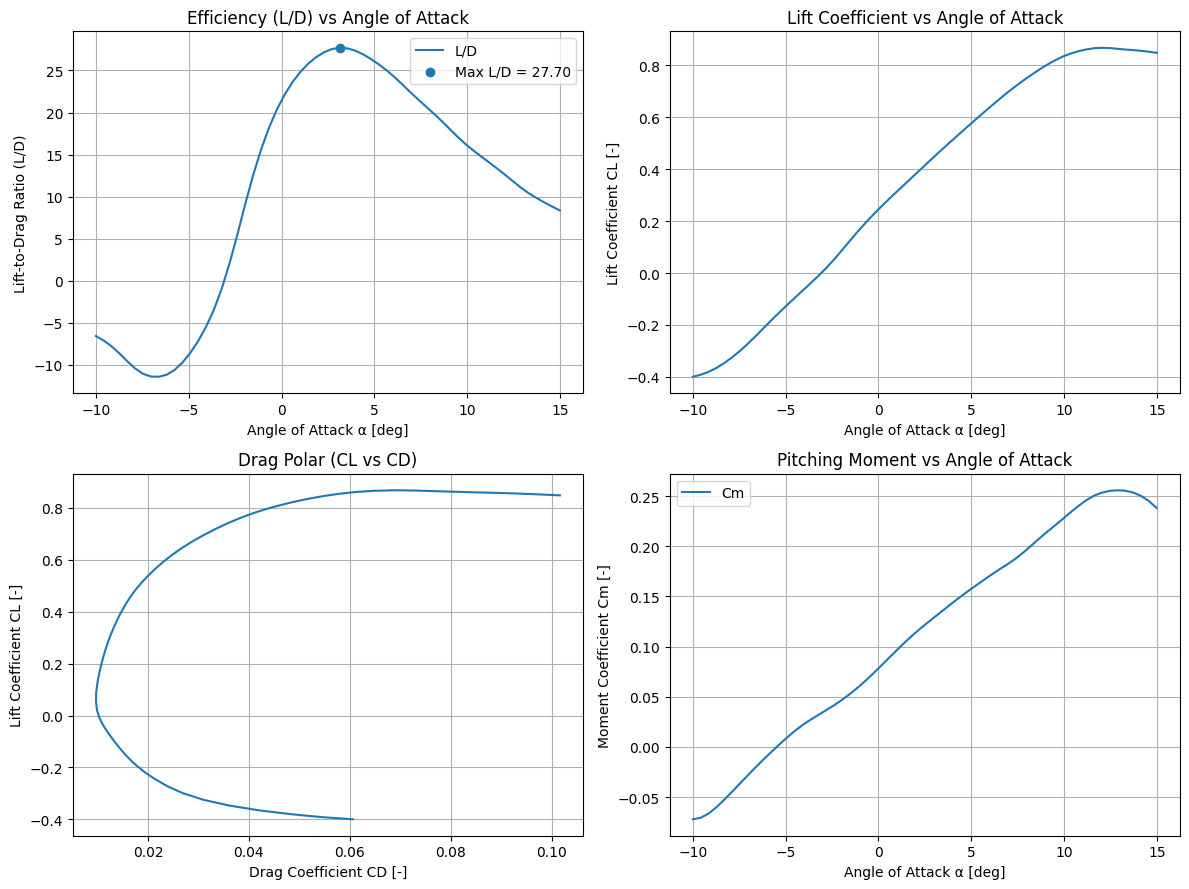


=== SUMMARY ===
Max L/D       : 27.70 at α = 3.14 deg
Oswald e      : 0.528


{'F_g': [array([-0.44698496, -0.51210702, -0.5788084 , -0.63735102, -0.66214831,
         -0.63553055, -0.55836557, -0.44550309, -0.31613185, -0.18458123,
         -0.05626886,  0.06405399,  0.17132597,  0.26328277,  0.33889861,
          0.400242  ,  0.45320032,  0.5027033 ,  0.54944569,  0.5889541 ,
          0.61378929,  0.61841994,  0.60071215,  0.5610938 ,  0.50125251,
          0.42297727,  0.32750005,  0.21538027,  0.08676617, -0.05815952,
         -0.21869359, -0.39334982, -0.58044624, -0.77911637, -0.98927842,
         -1.21096356, -1.44389296, -1.68710796, -1.9385637 , -2.19611665,
         -2.45901343, -2.7273703 , -3.00017271, -3.27396274, -3.54286148,
         -3.80163237, -4.04921309, -4.28746382, -4.5178605 , -4.73668953,
         -4.93577318, -5.10702494, -5.24109353, -5.32797075, -5.37948378,
         -5.43025612, -5.49093152, -5.54492008, -5.58174685, -5.5995675 ]),
  array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0

In [ ]:
alphaSweep = analyze_alpha_sweep_and_plot(airplane, TARGET_VELOCITY, np.linspace(-10, 20, 60), metrics['Aerodynamic center'])
alphaSweep['raw_result']


In [16]:
print(alphaSweep['raw_result']['wing_aero_components'][0].oswalds_efficiency)
print(f"keys: {list(alphaSweep['raw_result'].keys())}")
res = alphaSweep['raw_result']
print(f"Neutral point: {res['x_np']}")
print(f"center of gravity: {res['x_cg']}")
#alphaSweep['raw_result']['Clb']

0.8051270316816461
keys: ['F_g', 'M_g', 'F_b', 'F_w', 'M_b', 'M_w', 'L', 'Y', 'D', 'l_b', 'm_b', 'n_b', 'CL', 'CY', 'CD', 'Cl', 'Cm', 'Cn', 'wing_aero_components', 'fuselage_aero_components', 'D_profile', 'D_induced', 'CLa', 'CDa', 'CYa', 'Cla', 'Cma', 'Cna', 'x_np', 'CLb', 'CDb', 'CYb', 'Clb', 'Cmb', 'Cnb', 'x_np_lateral', 'CLp', 'CDp', 'CYp', 'Clp', 'Cmp', 'Cnp', 'CLq', 'CDq', 'CYq', 'Clq', 'Cmq', 'Cnq', 'CLr', 'CDr', 'CYr', 'Clr', 'Cmr', 'Cnr']
Neutral point: [ 2.54473149e-01  1.86199296e-01  1.61477985e-01  1.60523212e-01
  1.68037673e-01  1.76752643e-01  1.84872445e-01  1.90887513e-01
  1.96521197e-01  1.99797455e-01  1.99609156e-01  1.99411071e-01
  2.00756714e-01  2.04997162e-01  2.10975482e-01  2.16360711e-01
  2.19776493e-01  2.21775651e-01  2.22543753e-01  2.21152579e-01
  2.17548318e-01  2.12373701e-01  2.06482890e-01  2.00845195e-01
  1.96449074e-01  1.94077474e-01  1.94081420e-01  1.96273889e-01
  1.99935612e-01  2.03749637e-01  2.05833506e-01  2.05319714e-01
  2.04194439e

KeyError: 'x_cg'

In [20]:
alphaSweep['raw_result']['x_np']

array([0.46115462, 0.46333502, 0.46684013, 0.46733049, 0.46644334,
       0.46638698, 0.46718297, 0.4675588 , 0.46770973, 0.46870863,
       0.46956293, 0.46963339, 0.46982875, 0.47065826, 0.47098998,
       0.46968359, 0.46725372, 0.46493801, 0.46350917, 0.46328293,
       0.46419279, 0.4660982 , 0.4690357 , 0.47304456, 0.47798089,
       0.48320239, 0.4874972 , 0.48998873, 0.49081303, 0.49073355,
       0.49046121, 0.49037948, 0.49061141, 0.49111704, 0.49177427,
       0.49247559, 0.49317851, 0.4939219 , 0.49476043, 0.49556314,
       0.49593095, 0.49545234, 0.49403984, 0.49201285, 0.48988896,
       0.48805179, 0.48659974, 0.48545777, 0.48444885, 0.48327637,
       0.48170609, 0.4798944 , 0.4785175 , 0.47866853, 0.4818328 ,
       0.49019728, 0.5074839 , 0.54108614, 0.60895778, 0.77317541])

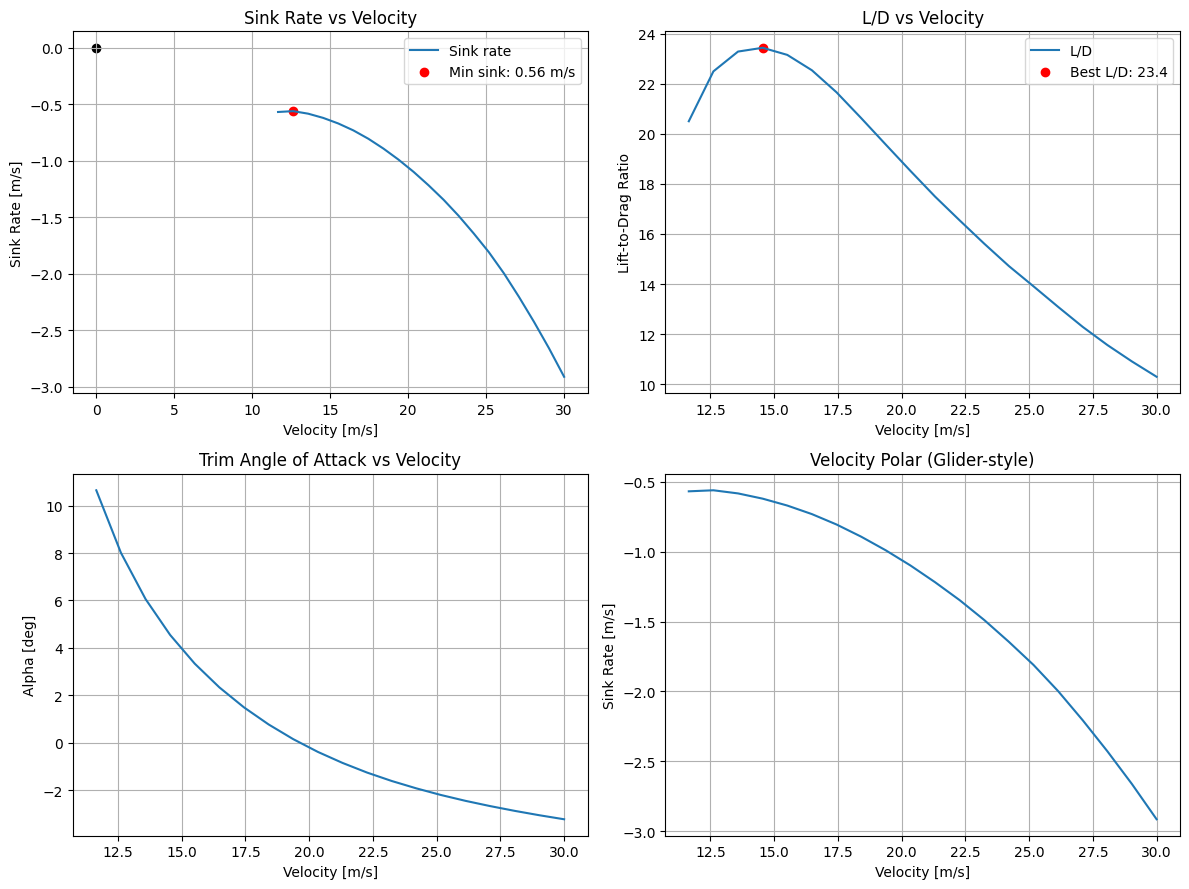


=== VELOCITY POLAR SUMMARY ===
Min sink speed   : 12.62 m/s
Min sink rate    : 0.56 m/s
Best glide speed : 14.55 m/s
Max L/D          : 23.43


In [21]:
velocities = np.linspace(2, 30, 30)

polar = analyze_velocity_polar(
    airplane=airplane,
    mass=1.5,
    velocities=velocities
)

In [22]:
op = asb.OperatingPoint(velocity=TARGET_VELOCITY, alpha=2)
ab = asb.AeroBuildup(  # This sets up the analysis, but doesn't execute calculation
    airplane=airplane,  # type: asb.Airplane
    op_point=op,  # type: asb.OperatingPoint
    xyz_ref=[results['x_cg'], 0, 0],  # Moment reference and center of rotation.
)
aero = ab.run()  # This executes the actual aero analysis.
aero_with_stability_derivs = ab.run_with_stability_derivatives() 

In [14]:
plot_wing_performance(results, airplane)

KeyError: 'vlm_obj'

Wyniki analizy:
L/D: 30.41
Static Margin: 8.00%
Cn-beta (Boczna): 0.0145
Lift Coefficient: 0.2081
Trim moment Coefficient: 0.0185
Center of Gravity: 0.1716,
Neutral Point: 0.1842

Wyniki analizy:
L/D: 27.89
Static Margin: 8.00%
Cn-beta (Boczna): 0.0501
Lift Coefficient: 0.1957
Trim moment Coefficient: 0.0251
Center of Gravity: 0.1741,
Neutral Point: 0.1864


Wyniki analizy:
L/D: 18.52
Static Margin: 8.00%
Cn-beta (Boczna): 0.1460
Lift Coefficient: 0.2068
Trim moment Coefficient: 0.0050
Center of Gravity: 0.1753,
Neutral Point: 0.1877